In [6]:
import utils
import train
import matplotlib.pyplot as plt
import numpy as np
import torch
from train import x
from argparse import ArgumentParser
from argparse import *
import os
import pickle
from textwrap import wrap
from utils import Generator
import scipy
import math

In [7]:
x = np.random.normal(1, 1.5, 5)

In [8]:
#replace x by its sufficient statistics (x mean)
xbar  = np.mean(x)
x2bar = np.mean(x**2)
n = len(x)

In [9]:
print(x.mean())
print(np.log(x.std()))

1.1654835082404058
0.46381094166918013


In [10]:
mu_k = np.linspace(0, 2, 10)
eta_k = np.linspace(0, 1, 10)

MU_K, ETA_K = np.meshgrid(mu_k, eta_k )

In [11]:
def log_likelihood(mu_k, eta_k,x):
    logpdf = scipy.stats.distributions.norm.logpdf(x, mu_k, math.exp(eta_k)).sum()
    return logpdf

In [12]:
def derivative_ll_mu(mu_k, eta_k, xbar, x2bar, n):
    return np.exp(-2 * eta_k) * (n* xbar - n * mu_k)
    

In [13]:
def derivative_ll_eta(mu_k, eta_k, xbar, x2bar, n):
    return n * (x2bar - 2 * mu_k * xbar + mu_k**2) * np.exp(-2 * eta_k) -n

In [14]:
def approx_derivative_ll_mu(mu_k, eta_k, xbar, x2bar, n):
    return np.exp(-2 * eta_k) * (n* xbar - n * mu_k)
    

In [15]:
def approx_derivative_ll_eta(mu_k, eta_k, xbar, x2bar, n):
    return n * (x2bar - 2 * mu_k * xbar + mu_k**2) * np.exp(-2 * eta_k) 

In [16]:
muhat = x.mean()

sigmahat = np.sqrt(  np.sum((x-xbar)**2) /(n-1) )
mle = np.sqrt( np.sum((x-xbar)**2) /(n))
etahat = np.log(mle) #either use unbiased estimator np.log(x.std())  or (better) use mle : avg((x - xbar)**2)
#with these values both derivates should go to 0 

In [17]:
derivative_ll_mu(muhat, etahat, xbar, x2bar, n)

0.0

In [18]:
derivative_ll_eta(muhat, etahat, xbar, x2bar, n) 

1.7763568394002505e-15

In [19]:
ll = np.zeros_like(MU_K)

for i in range(MU_K.shape[0]):
    for j in range(MU_K.shape[1]):
        ll[i,j] = log_likelihood(MU_K[i,j], ETA_K[i,j], x)

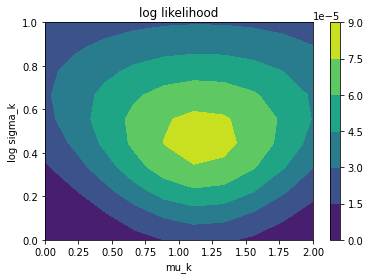

In [20]:
fig,ax=plt.subplots(1,1)
cp = ax.contourf(MU_K, ETA_K, np.exp(ll))
fig.colorbar(cp) # Add a colorbar to a plot
plt.xlabel('mu_k')
plt.ylabel('log sigma_k')
plt.title('log likelihood')
plt.show()

The above plot is good as the highest point (lightest) corresponds to the exact mu and logsigma 

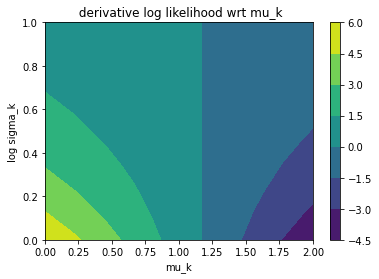

In [21]:
ll2 = np.zeros_like(MU_K)

for i in range(MU_K.shape[0]):
    for j in range(MU_K.shape[1]):
        ll2[i,j] = derivative_ll_mu(MU_K[i,j], ETA_K[i,j], xbar, x2bar, n)
        
fig,ax=plt.subplots(1,1)
cp = ax.contourf(MU_K, ETA_K,ll2)
fig.colorbar(cp) # Add a colorbar to a plot
plt.xlabel('mu_k')
plt.ylabel('log sigma_k')
plt.title(' derivative log likelihood wrt mu_k')
#ax.set_xlim([4, 6])
plt.show()

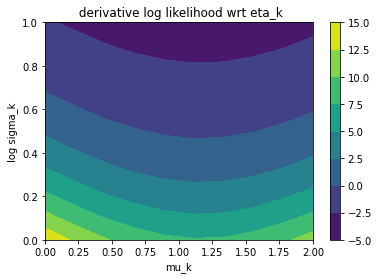

In [22]:
ll3 = np.zeros_like(MU_K)

for i in range(MU_K.shape[0]):
    for j in range(MU_K.shape[1]):
        ll3[i,j] = derivative_ll_eta(MU_K[i,j], ETA_K[i,j], xbar, x2bar, n)
        
fig,ax=plt.subplots(1,1)
cp = ax.contourf(MU_K, ETA_K, ll3)
fig.colorbar(cp) # Add a colorbar to a plot
plt.xlabel('mu_k')
plt.ylabel('log sigma_k')
plt.title(' derivative log likelihood wrt eta_k')
plt.show()

In [23]:
#vector field stuff 

In [24]:
#ll2 = np.ones(100)*4.7
#ll3 = np.ones(100)*(1.1)

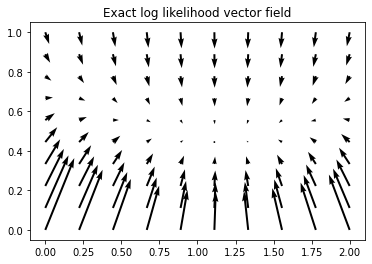

In [25]:
fig,ax=plt.subplots(1,1)
plt.quiver(MU_K,ETA_K, ll2, ll3)
#ax.set_xlim([3.9,6.1])
#ax.set_ylim([0.8,2.5])
plt.title('Exact log likelihood vector field')
plt.show()

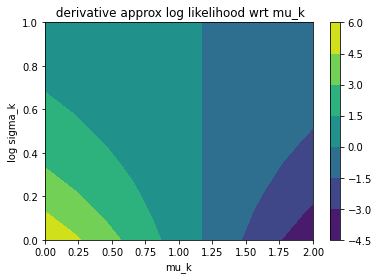

In [26]:
approx_ll2 = np.zeros_like(MU_K)

for i in range(MU_K.shape[0]):
    for j in range(MU_K.shape[1]):
        approx_ll2[i,j] = approx_derivative_ll_mu(MU_K[i,j], ETA_K[i,j], xbar, x2bar, n)
        
fig,ax=plt.subplots(1,1)
cp = ax.contourf(MU_K, ETA_K,ll2)
fig.colorbar(cp) # Add a colorbar to a plot
plt.xlabel('mu_k')
plt.ylabel('log sigma_k')
plt.title(' derivative approx log likelihood wrt mu_k')
#ax.set_xlim([4, 6])
plt.show()

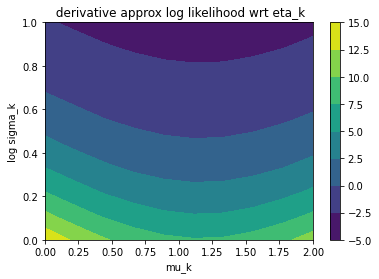

In [27]:
approx_ll3 = np.zeros_like(MU_K)

for i in range(MU_K.shape[0]):
    for j in range(MU_K.shape[1]):
        approx_ll3[i,j] = approx_derivative_ll_eta(MU_K[i,j], ETA_K[i,j], xbar, x2bar, n)
        
fig,ax=plt.subplots(1,1)
cp = ax.contourf(MU_K, ETA_K, ll3)
fig.colorbar(cp) # Add a colorbar to a plot
plt.xlabel('mu_k')
plt.ylabel('log sigma_k')
plt.title(' derivative approx log likelihood wrt eta_k')
plt.show()

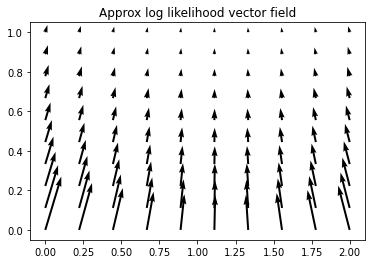

In [28]:
fig,ax=plt.subplots(1,1)
plt.quiver(MU_K,ETA_K, approx_ll2, approx_ll3)
#ax.set_xlim([3.9,6.1])
#ax.set_ylim([0.8,2.5])
plt.title('Approx log likelihood vector field')
plt.show()

In [29]:
mu_old = 0.001
eta_old = 0.001
step_size = 0.2

In [30]:
mu_new = mu_old +  derivative_ll_mu(mu_k, eta_k, xbar, x2bar, n) * step_size 
eta_new = eta_old + derivative_ll_eta(mu_k, eta_k, xbar, x2bar, n) * step_size 

In [31]:
#iterate the above and reduce step size ?

In [32]:
#SGD UPDTATES

In [33]:
#replace x by its sufficient statistics (x mean)
xbar  = np.mean(x)
x2bar = np.mean(x**2)
n = len(x)

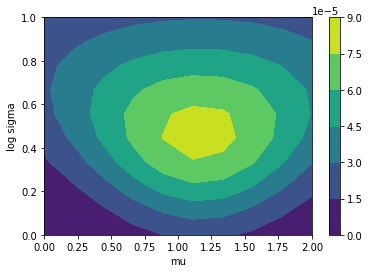

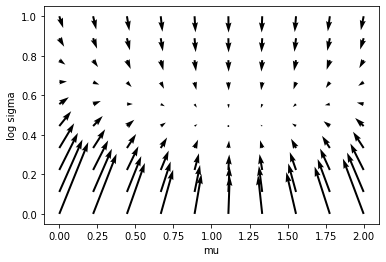

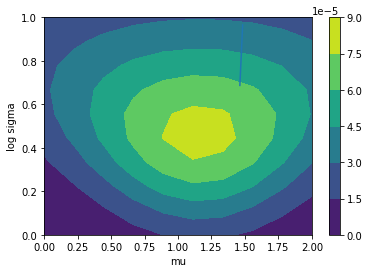

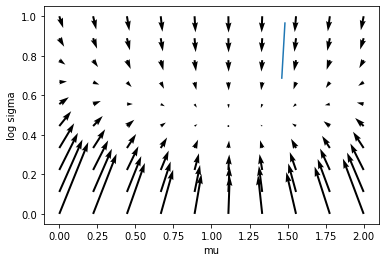

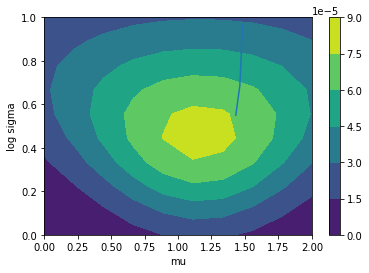

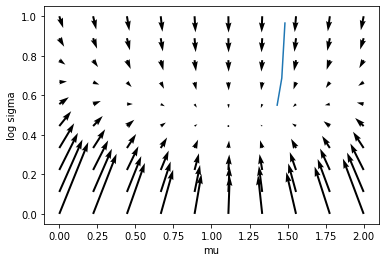

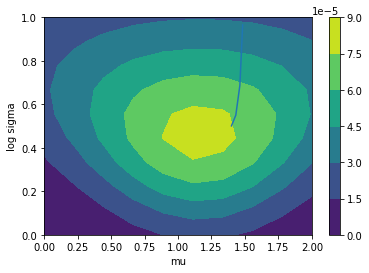

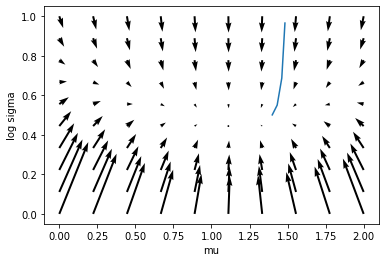

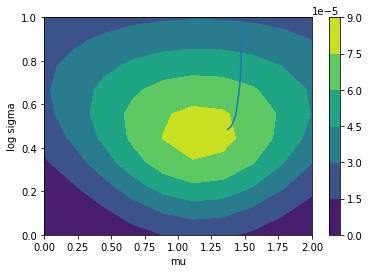

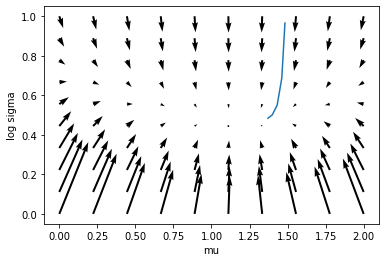

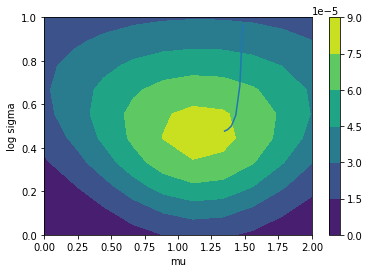

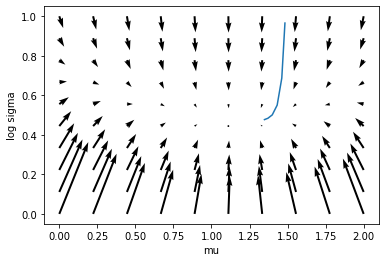

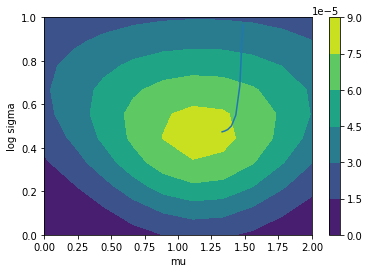

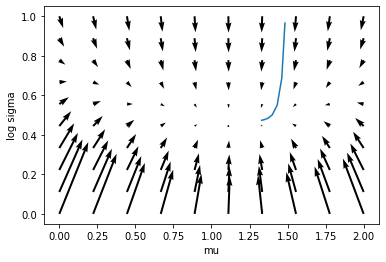

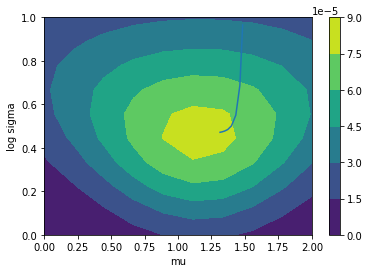

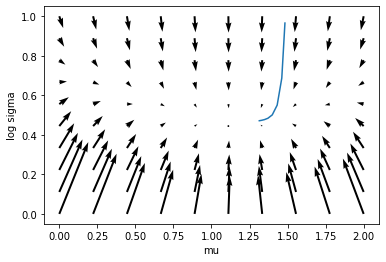

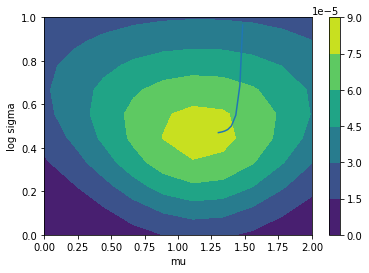

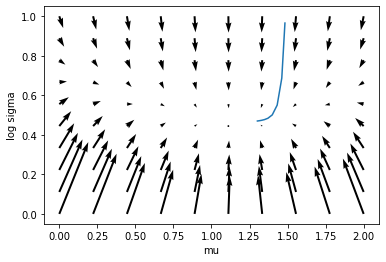

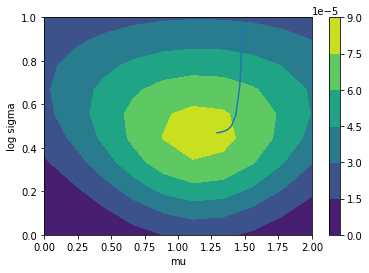

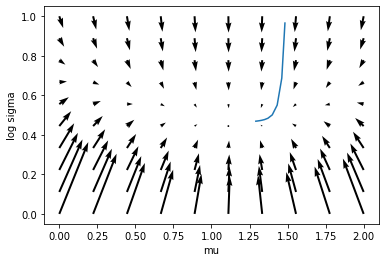

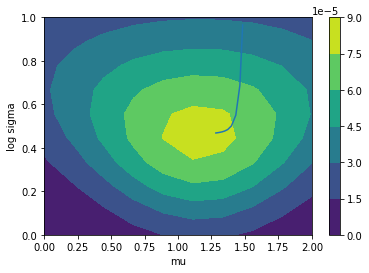

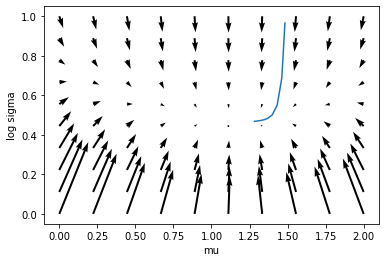

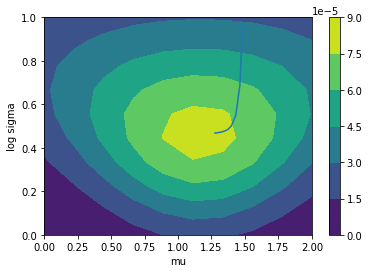

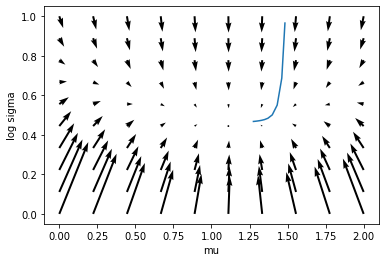

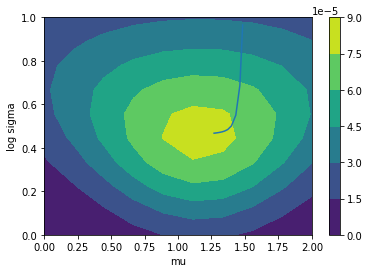

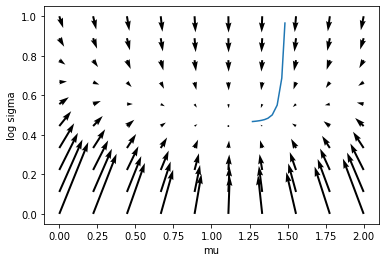

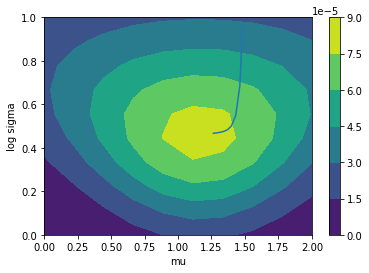

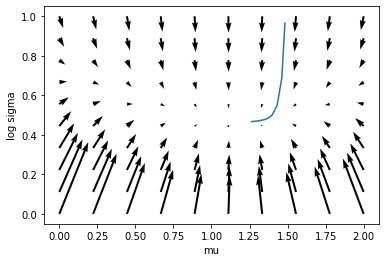

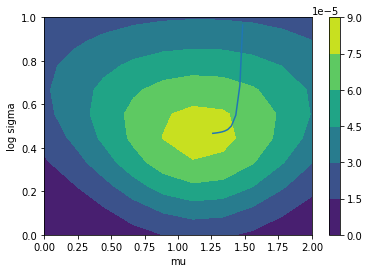

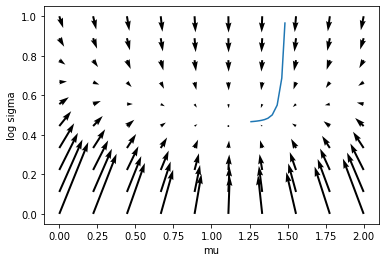

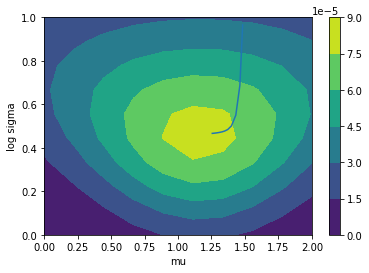

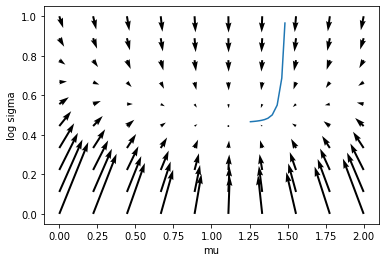

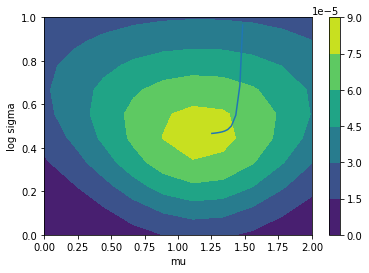

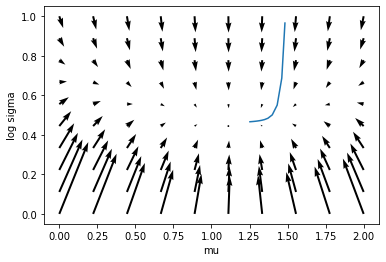

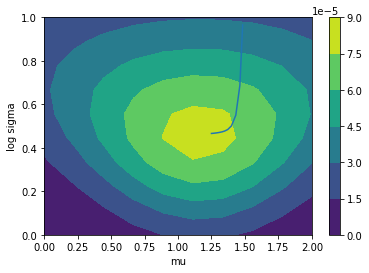

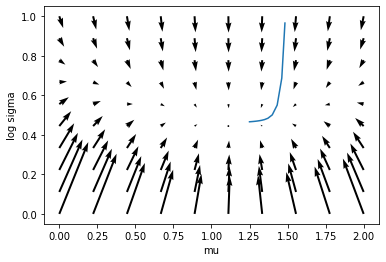

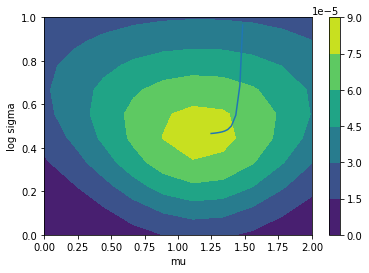

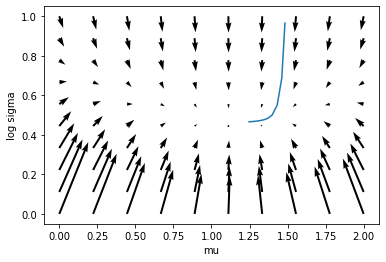

In [85]:
etas=[]
mus=[]
mu_old = 1.8
eta_old = 0
step_size = 0.1
for i in range(1,20):
    #step_size = i**(-0.6)
    mu_new = mu_old + derivative_ll_mu(mu_old, eta_old, xbar, x2bar, n) * step_size 
    eta_new = eta_old + derivative_ll_eta(mu_old, eta_old, xbar, x2bar, n) * step_size 
    step_size = step_size * 0.9
    mu_old  = mu_new
    eta_old = eta_new 
    etas.append(eta_old)
    mus.append(mu_old)
    
    fig,ax=plt.subplots(1,1)
    cp = ax.contourf(MU_K, ETA_K, np.exp(ll))
    fig.colorbar(cp)
    plt.plot(mus, etas)
    plt.xlabel('mu')
    plt.ylabel('log sigma')
    plt.savefig('/home/i.sebag/sync/PWGAN/plots/llsgd_%s'%i)
    plt.show()
    
    fig,ax=plt.subplots(1,1)
    plt.quiver(MU_K,ETA_K, ll2, ll3)
    plt.plot(mus, etas)
    plt.xlabel('mu')
    plt.ylabel('log sigma')
    plt.savefig('/home/i.sebag/sync/PWGAN/plots/vfsgd_%s'%i)
    #plt.title('Exact log likelihood vector field')
    plt.show()
    

In [86]:
#fig,ax=plt.subplots(1,1)
#cp = ax.contourf(MU_K, ETA_K, np.exp(ll))
#fig.colorbar(cp)
#plt.plot(mus, etas)
#plt.show()

In [87]:
#fig,ax=plt.subplots(1,1)
#plt.quiver(MU_K,ETA_K, ll2, ll3)
#plt.plot(mus, etas)
#plt.title('Exact log likelihood vector field')
#plt.show()

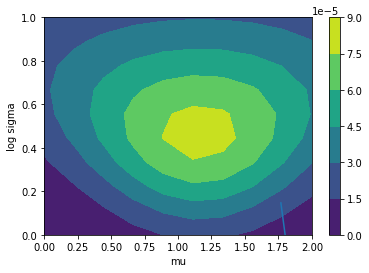

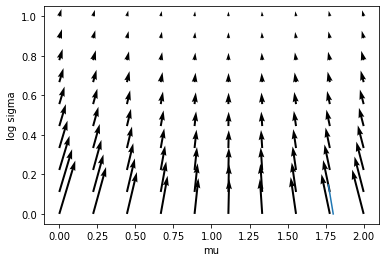

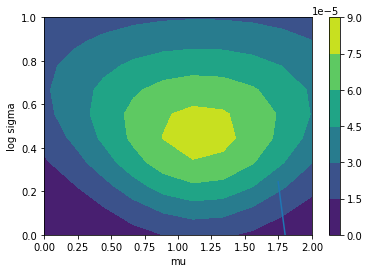

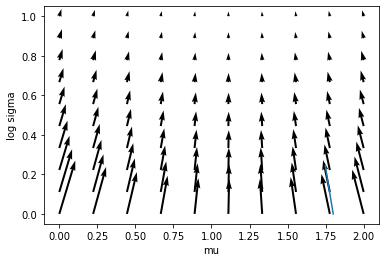

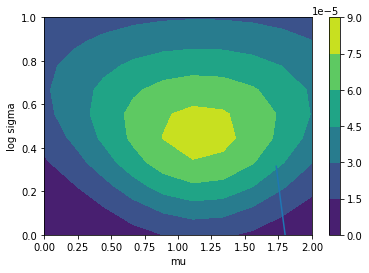

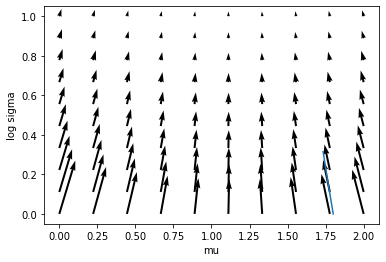

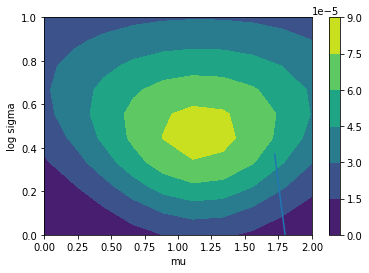

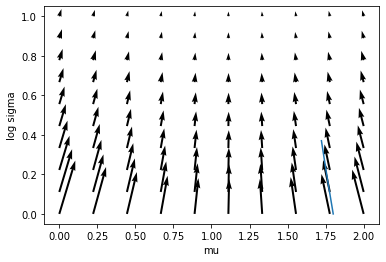

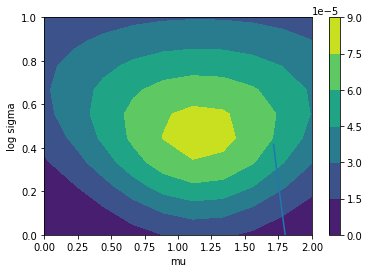

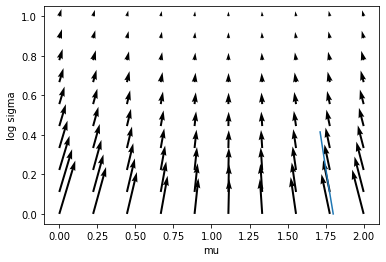

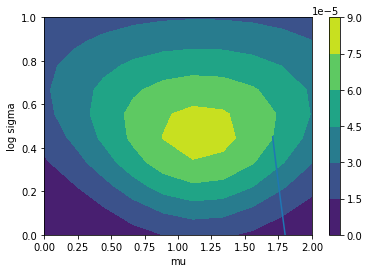

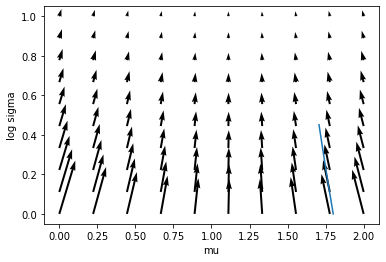

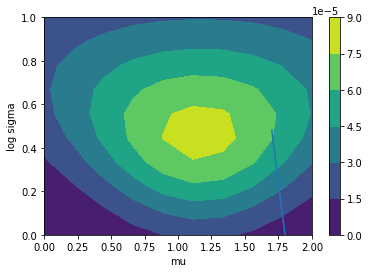

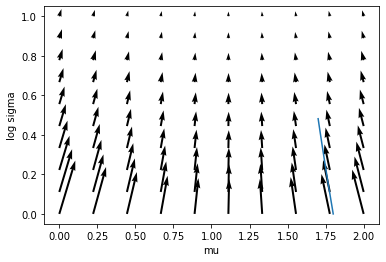

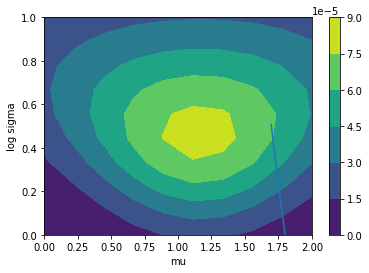

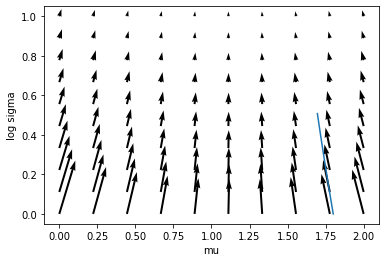

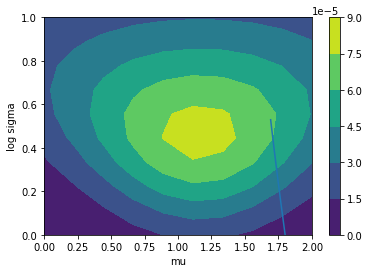

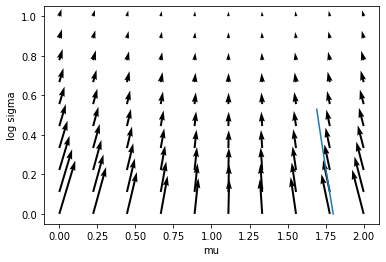

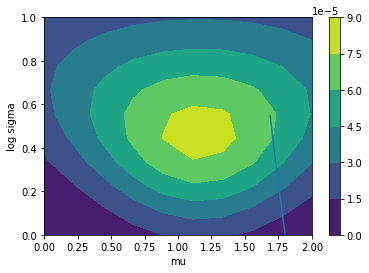

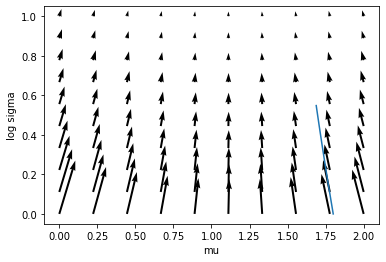

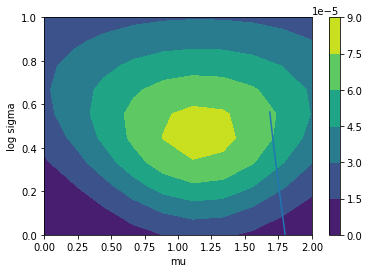

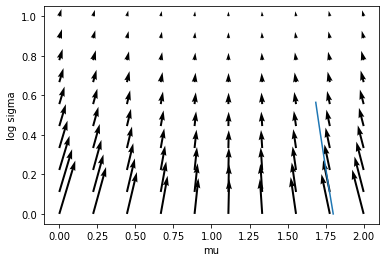

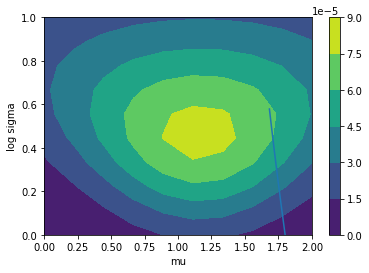

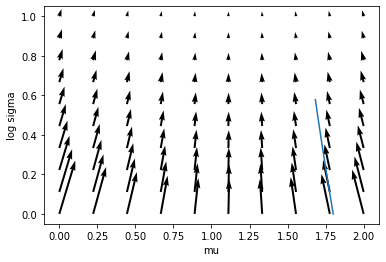

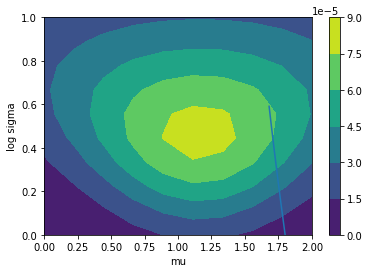

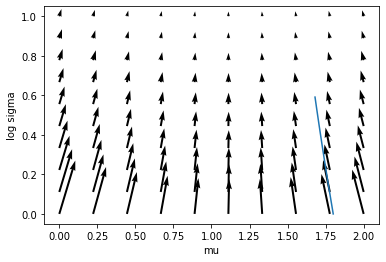

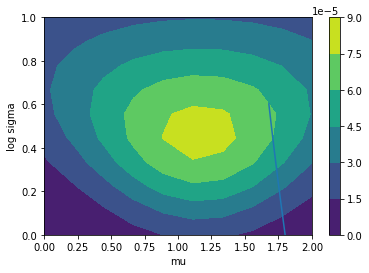

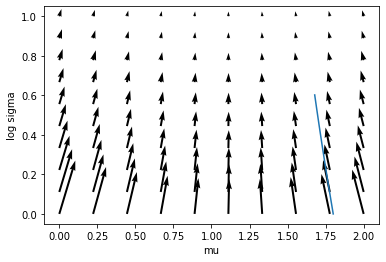

In [89]:
mu_old = 1.8
eta_old = 0
etas=[eta_old]
mus=[mu_old]
step_size = 0.01
for i in range(1,15):
    #step_size = i**(-0.6)
    mu_new = mu_old + approx_derivative_ll_mu(mu_old, eta_old, xbar, x2bar, n) * step_size 
    eta_new = eta_old + approx_derivative_ll_eta(mu_old, eta_old, xbar, x2bar, n) * step_size 
    step_size = step_size * 0.9
    mu_old  = mu_new
    eta_old = eta_new 
    etas.append(eta_old)
    mus.append(mu_old)
    
    fig,ax=plt.subplots(1,1)
    cp = ax.contourf(MU_K, ETA_K, np.exp(ll))
    fig.colorbar(cp)
    plt.plot(mus, etas)
    plt.xlabel('mu')
    plt.ylabel('log sigma')
    plt.savefig('/home/i.sebag/sync/PWGAN/plots/approxllsgd_%s'%i)
    plt.show()
    
    fig,ax=plt.subplots(1,1)
    plt.quiver(MU_K,ETA_K, approx_ll2, approx_ll3)
    plt.plot(mus, etas)
    plt.xlabel('mu')
    plt.ylabel('log sigma')
    plt.savefig('/home/i.sebag/sync/PWGAN/plots/approxvfsgd_%s'%i)
    #plt.title('Exact log likelihood vector field')
    plt.show()

In [90]:
#fig,ax=plt.subplots(1,1)
#cp = ax.contourf(MU_K, ETA_K, np.exp(ll))
#fig.colorbar(cp)
#plt.plot(mus, etas)
#plt.show()

In [91]:
#fig,ax=plt.subplots(1,1)
#plt.quiver(MU_K,ETA_K, approx_ll2, approx_ll3)
#plt.plot(mus, etas)
#plt.title('Exact log likelihood vector field')
#plt.show()

In [607]:
optimizer_D.zero_grad()
loss_D = - torch.mean(Dx) + torch.mean(Df)
loss_D.backward()
optimizer_D.step()

NameError: name 'optimizer_D' is not defined

In [ ]:
mu_old = 0
eta_old = 0
etas=[eta_old]
mus=[mu_old]
step_size = 0.01
for i in range(1,15):
    #step_size = i**(-0.6)
    #mu_new = mu_old + approx_derivative_ll_mu(mu_old, eta_old, xbar, x2bar, n) * step_size 
    #eta_new = eta_old + approx_derivative_ll_eta(mu_old, eta_old, xbar, x2bar, n) * step_size 
    
    
    #create df --> generate fake data 
    muk = mu_old
    etak = eta_old 
    eps = ...
    xf = torch.rand(muk, etak)
    Dx = discriminator.o2_polynomial(x)
    optimizer_D.zero_grad()
    loss_D = - torch.mean(Dx) + torch.mean(xf)
    loss_D.backward()
    optimizer_D.step()
    
    #get back k params 

    #step_size = step_size * 0.9
    #mu_old  = mu_new
    #eta_old = eta_new 
    etas.append(mu_k.item())
    mus.append(eta_k.item())
    
    